<a href="https://colab.research.google.com/github/chenp0728-glitch/--Module1-/blob/main/M1_%E5%82%85%E7%AB%8B%E8%91%89.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

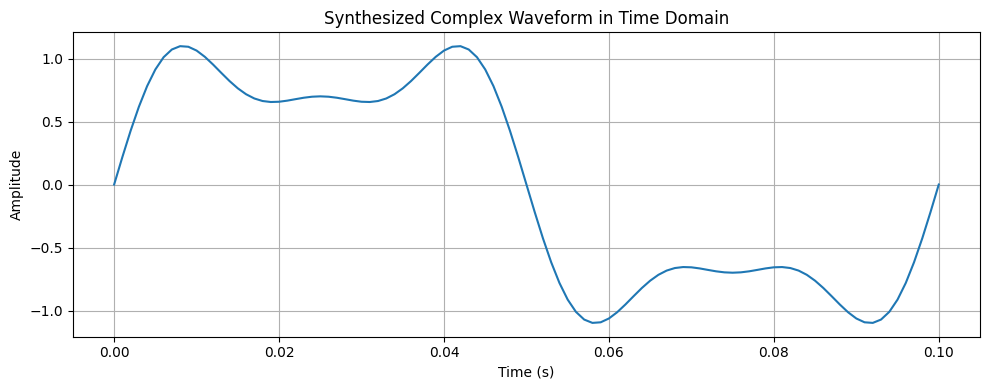

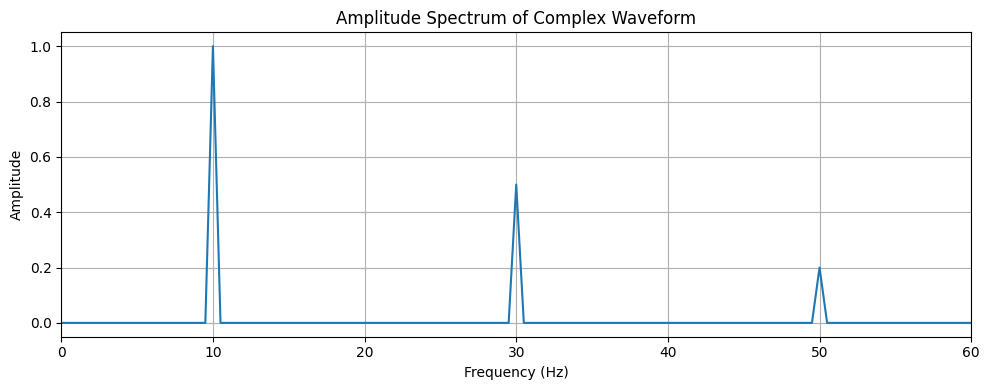

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. 合成訊號: 用 Python 寫一個函數, 疊加三個不同頻率、不同振幅的正弦波
def synthesize_complex_signal(t, frequencies, amplitudes):
    """
    疊加多個正弦波來合成一個複雜訊號。

    Args:
        t (np.ndarray): 時間點陣列。
        frequencies (list): 各正弦波的頻率 (Hz)。
        amplitudes (list): 各正弦波的振幅。

    Returns:
        np.ndarray: 合成後的複雜訊號。
    """
    if len(frequencies) != len(amplitudes):
        raise ValueError("頻率和振幅的列表長度必須相同")

    signal = np.zeros_like(t, dtype=float)
    for freq, amp in zip(frequencies, amplitudes):
        signal += amp * np.sin(2 * np.pi * freq * t)
    return signal

# 使用與白噪音範例相同的取樣參數以便比較
# 這些變數 (sampling_rate, duration, number_of_samples, t) 應該已由前一個儲存格 gWm7bC8qZvUZ 定義

# 設定合成訊號的頻率和振幅 (例如 y = sin(2π10t) + 0.5sin(2π30t) + 0.2sin(2π50t))
base_freq = 10  # 基礎頻率 (Hz)
frequencies = [base_freq, 3 * base_freq, 5 * base_freq] # 例: 10Hz, 30Hz, 50Hz
amplitudes = [1.0, 0.5, 0.2]  # 例: 1.0, 0.5, 0.2

# 合成複雜訊號
y = synthesize_complex_signal(t, frequencies, amplitudes)


# 2. 觀察波形: 畫出 y(t), 這看起來是一個複雜的波。
plt.figure(figsize=(10, 4))
# 為了清楚顯示，只繪製前 0.1 秒的波形
display_mask = t <= 0.1
plt.plot(t[display_mask], y[display_mask])
plt.title("Synthesized Complex Waveform in Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


# 3. 破解訊號: 使用 numpy.fft.fft 進行轉換, 畫出頻譜圖。
fft_result = np.fft.fft(y)

# 建立每個 FFT 點所對應的頻率
fft_frequencies = np.fft.fftfreq(number_of_samples, d=1 / sampling_rate)

# 只保留正頻率部分
positive_mask = fft_frequencies >= 0
positive_frequencies = fft_frequencies[positive_mask]

# 計算單邊振幅頻譜
# N 為採樣點數
# 將除了 DC (f=0) 以外的所有正頻率振幅乘以 2 (因為負頻率部分也包含能量)
amplitude_spectrum = 2 / number_of_samples * np.abs(fft_result[positive_mask])
# DC 分量 (頻率為 0) 不需要乘以 2
amplitude_spectrum[0] = amplitude_spectrum[0] / 2


# 4. 視覺化: 你會看到頻譜圖上出現了三根 '針'
plt.figure(figsize=(10, 4))
plt.plot(positive_frequencies, amplitude_spectrum)
plt.title("Amplitude Spectrum of Complex Waveform")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
# 將 x 軸顯示範圍限制在合理範圍，例如 Nyquist 頻率 (sampling_rate / 2)
plt.xlim(0, sampling_rate / 2)
# 可以進一步限制 x 軸範圍，使針更明顯，例如只顯示到 60 Hz
plt.xlim(0, 60)
plt.xticks(np.arange(0, 60 + 1, 10)) # 調整 x 軸刻度以提高可讀性
plt.grid(True)
plt.tight_layout()
plt.show()

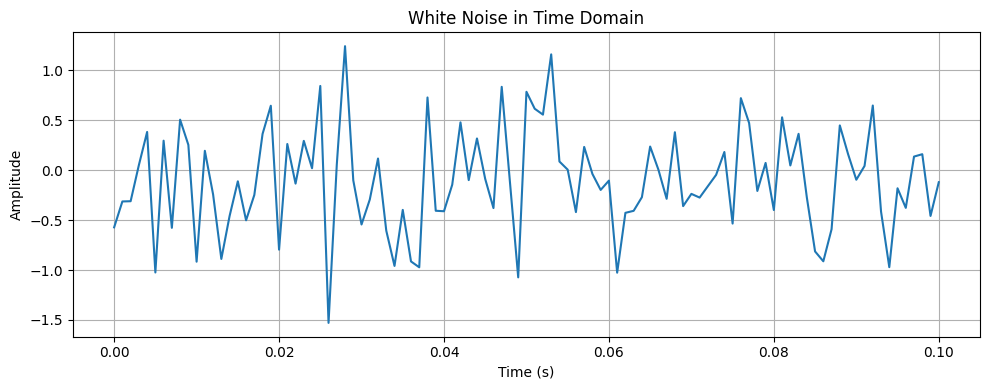

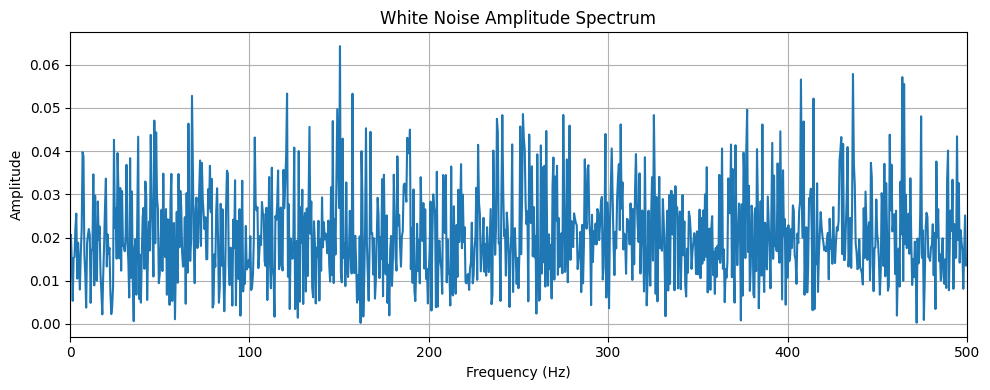

--------------------------------------------------------------------------------
總結：
當時間域波形雜亂，但頻譜圖有乾淨的 '針' 時，表示訊號由特定的頻率成分組成，具有明確的週期性。
而白噪音的頻譜圖則呈現平坦且寬廣的分佈，沒有明顯的峰值，代表其能量均勻分佈在所有頻率上，不具週期性。


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==================================================
# 白噪音範例
# ==================================================

# 使用與之前合成訊號相同的取樣參數以便比較
sampling_rate = 1000       # 取樣頻率 fs = 1000 Hz
duration = 2               # 取樣時間 2 秒
number_of_samples = int(sampling_rate * duration)

t = np.linspace(
    0,
    duration,
    number_of_samples,
    endpoint=False
)

# 產生白噪音訊號 (使用高斯分佈的隨機數)
# 注意：理想的白噪音在現實中難以實現，這裡使用隨機數模擬
white_noise = np.random.randn(number_of_samples) * 0.5 # 乘以0.5控制振幅


# ==================================================
# 白噪音時域波形
# ==================================================

plt.figure(figsize=(10, 4))

# 只顯示前 0.1 秒，使波形比較清楚
display_mask_noise = t <= 0.1

plt.plot(t[display_mask_noise], white_noise[display_mask_noise])

plt.title("White Noise in Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()


# ==================================================
# 白噪音頻譜圖
# ==================================================

fft_result_noise = np.fft.fft(white_noise)

# 建立每個 FFT 點所對應的頻率
fft_frequencies_noise = np.fft.fftfreq(
    number_of_samples,
    d=1 / sampling_rate
)

# 只保留正頻率部分
positive_mask_noise = fft_frequencies_noise >= 0
positive_frequencies_noise = fft_frequencies_noise[positive_mask_noise]

# 單邊振幅頻譜
amplitude_spectrum_noise = (
    2 / number_of_samples
    * np.abs(fft_result_noise[positive_mask_noise])
)

# 直流分量不應乘以 2
amplitude_spectrum_noise[0] /= 2


plt.figure(figsize=(10, 4))

plt.plot(
    positive_frequencies_noise,
    amplitude_spectrum_noise
)

plt.title("White Noise Amplitude Spectrum")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")

# 顯示到奈奎斯特頻率，即取樣頻率的一半
plt.xlim(0, sampling_rate / 2)
plt.grid(True)
plt.tight_layout()

plt.show()

print("--------------------------------------------------------------------------------")
print("總結：")
print("當時間域波形雜亂，但頻譜圖有乾淨的 '針' 時，表示訊號由特定的頻率成分組成，具有明確的週期性。")
print("而白噪音的頻譜圖則呈現平坦且寬廣的分佈，沒有明顯的峰值，代表其能量均勻分佈在所有頻率上，不具週期性。")

### 嘗試加入雜訊

我們將把之前生成的白噪音加入到合成訊號中，然後觀察頻譜圖的變化。

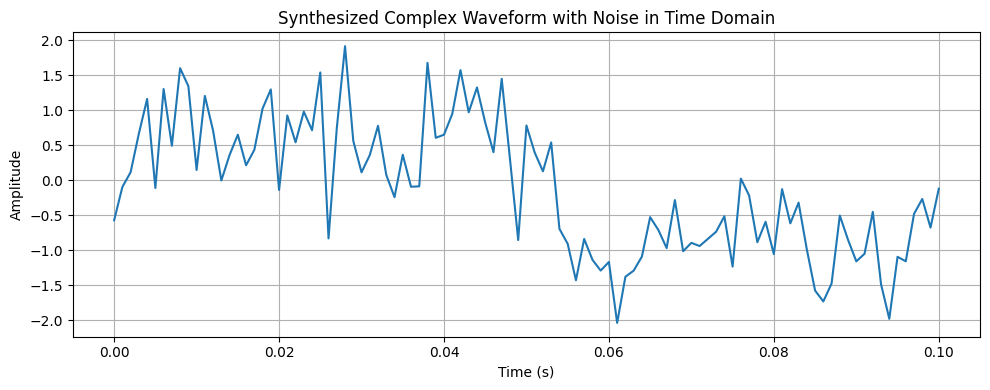

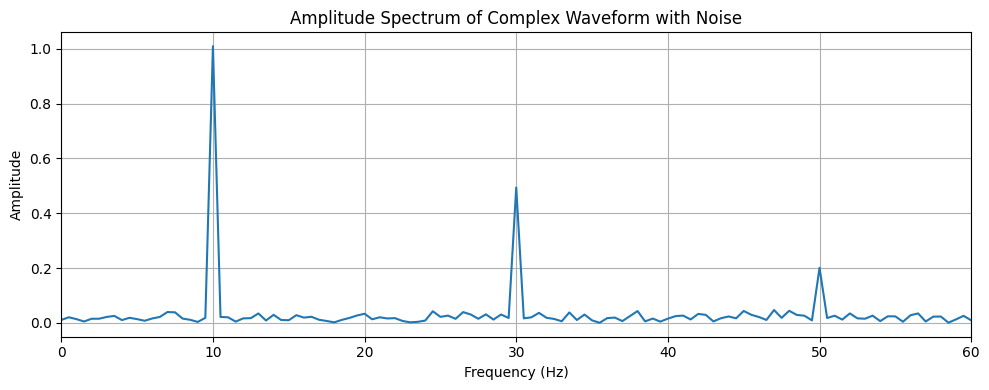

In [ ]:
# 將合成訊號與白噪音疊加
# 確保兩個訊號的長度相同
if len(y) != len(white_noise):
    print(f"Warning: Lengths of synthesized signal ({len(y)}) and white noise ({len(white_noise)}) do not match. Adjusting length.")
    # 取較短的長度以避免錯誤
    min_len = min(len(y), len(white_noise))
    y_noisy = y[:min_len] + white_noise[:min_len]
else:
    y_noisy = y + white_noise


# 觀察帶有雜訊的波形
plt.figure(figsize=(10, 4))
# 為了清楚顯示，只繪製前 0.1 秒的波形
display_mask = t <= 0.1
plt.plot(t[display_mask], y_noisy[display_mask])
plt.title("Synthesized Complex Waveform with Noise in Time Domain")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.tight_layout()
plt.show()


# 對帶有雜訊的訊號進行 FFT 轉換
fft_result_noisy = np.fft.fft(y_noisy)

# 建立每個 FFT 點所對應的頻率 (使用相同的 FFT 頻率)
# fft_frequencies 已在之前的儲存格中定義

# 只保留正頻率部分
positive_mask_noisy = fft_frequencies >= 0
positive_frequencies_noisy = fft_frequencies[positive_mask_noisy]

# 計算單邊振幅頻譜 (N 為採樣點數)
amplitude_spectrum_noisy = 2 / number_of_samples * np.abs(fft_result_noisy[positive_mask_noisy])
# 直流分量 (頻率為 0) 不需要乘以 2
amplitude_spectrum_noisy[0] = amplitude_spectrum_noisy[0] / 2


# 視覺化帶有雜訊的頻譜圖
plt.figure(figsize=(10, 4))
plt.plot(positive_frequencies_noisy, amplitude_spectrum_noisy)
plt.title("Amplitude Spectrum of Complex Waveform with Noise")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
# 限制 x 軸顯示範圍，使原始的「針」和雜訊背景更明顯
plt.xlim(0, 60)
plt.xticks(np.arange(0, 60 + 1, 10)) # 調整 x 軸刻度以提高可讀性
plt.grid(True)
plt.tight_layout()
plt.show()

### 直流分量比較

現在我們來比較一下原始訊號、白噪音以及加入雜訊後的訊號的直流分量（0 Hz 頻率的振幅）。

In [ ]:
# 原始合成訊號的直流分量
dc_original_signal = amplitude_spectrum[0]

# 白噪音的直流分量
dc_white_noise = amplitude_spectrum_noise[0]

# 疊加雜訊後的訊號的直流分量
dc_noisy_signal = amplitude_spectrum_noisy[0]

print(f"原始合成訊號的直流分量 (0 Hz 振幅): {dc_original_signal:.6f}")
print(f"白噪音訊號的直流分量 (0 Hz 振幅):     {dc_white_noise:.6f}")
print(f"疊加雜訊後訊號的直流分量 (0 Hz 振幅): {dc_noisy_signal:.6f}")

print("\n--- 解釋 ---")
print("1. 原始合成訊號是由純正弦波組成，這些正弦波的平均值都是 0，所以其直流分量非常接近 0。")
print("2. 白噪音是隨機分佈的，其平均值（直流分量）理論上應該接近 0，但由於有限的取樣和隨機性，會有一些小的非零值。")
print("3. 疊加雜訊後的訊號的直流分量，會是原始訊號和白噪音直流分量的總和。因為原始訊號的直流分量接近 0，所以此時的直流分量主要反映了白噪音的平均值。")

原始合成訊號的直流分量 (0 Hz 振幅): 0.000000
白噪音訊號的直流分量 (0 Hz 振幅):     0.011029
疊加雜訊後訊號的直流分量 (0 Hz 振幅): 0.011029

--- 解釋 ---
1. 原始合成訊號是由純正弦波組成，這些正弦波的平均值都是 0，所以其直流分量非常接近 0。
2. 白噪音是隨機分佈的，其平均值（直流分量）理論上應該接近 0，但由於有限的取樣和隨機性，會有一些小的非零值。
3. 疊加雜訊後的訊號的直流分量，會是原始訊號和白噪音直流分量的總和。因為原始訊號的直流分量接近 0，所以此時的直流分量主要反映了白噪音的平均值。


### 加入直流偏移後觀察 0Hz 峰值變化

現在我們將為原始合成訊號 `y` 加入一個直流偏移，然後重新執行 FFT 並觀察 0 Hz 分量的變化。

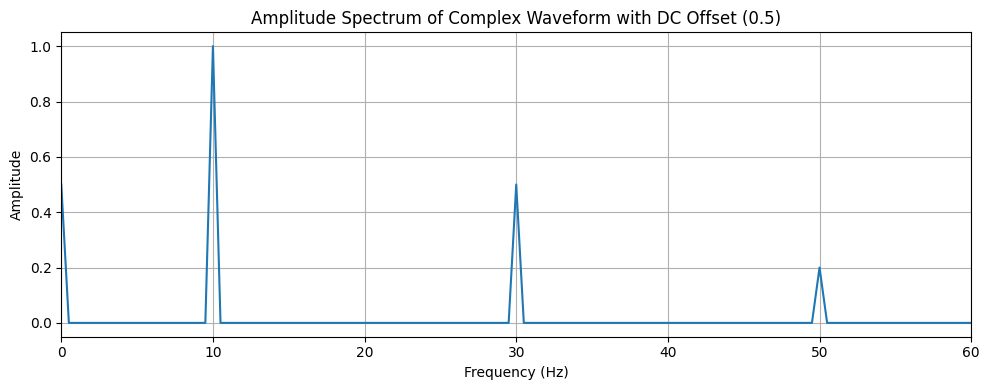

帶有直流偏移 (0.5) 訊號的直流分量 (0 Hz 振幅): 0.500000
原始合成訊號的直流分量 (0 Hz 振幅): 0.000000
設定的直流偏移值: 0.5
可以觀察到，加入直流偏移後，0 Hz 頻率的振幅顯著增加，並且與設定的偏移值相符。


In [ ]:
# 設定直流偏移量
dc_offset_value = 0.5
y_with_dc_offset = y + dc_offset_value

# 對帶有直流偏移的訊號進行 FFT 轉換
fft_result_dc_offset = np.fft.fft(y_with_dc_offset)

# 建立每個 FFT 點所對應的頻率 (使用相同的 FFT 頻率)
# fft_frequencies 已在之前的儲存格中定義

# 只保留正頻率部分
positive_mask_dc_offset = fft_frequencies >= 0
positive_frequencies_dc_offset = fft_frequencies[positive_mask_dc_offset]

# 計算單邊振幅頻譜
amplitude_spectrum_dc_offset = 2 / number_of_samples * np.abs(fft_result_dc_offset[positive_mask_dc_offset])
# 直流分量 (頻率為 0) 不需要乘以 2
amplitude_spectrum_dc_offset[0] = amplitude_spectrum_dc_offset[0] / 2

# 視覺化帶有直流偏移的頻譜圖
plt.figure(figsize=(10, 4))
plt.plot(positive_frequencies_dc_offset, amplitude_spectrum_dc_offset)
plt.title(f"Amplitude Spectrum of Complex Waveform with DC Offset ({dc_offset_value})")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude")
# 限制 x 軸顯示範圍，使原始的「針」和 0Hz 峰值更明顯
plt.xlim(0, 60)
plt.xticks(np.arange(0, 60 + 1, 10)) # 調整 x 軸刻度以提高可讀性
plt.grid(True)
plt.tight_layout()
plt.show()

# 輸出帶有直流偏移訊號的直流分量
dc_value_with_offset = amplitude_spectrum_dc_offset[0]
print(f"帶有直流偏移 ({dc_offset_value}) 訊號的直流分量 (0 Hz 振幅): {dc_value_with_offset:.6f}")
print(f"原始合成訊號的直流分量 (0 Hz 振幅): {dc_original_signal:.6f}")
print(f"設定的直流偏移值: {dc_offset_value}")
print("可以觀察到，加入直流偏移後，0 Hz 頻率的振幅顯著增加，並且與設定的偏移值相符。")